# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [2]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [3]:
print('Shape:', df.shape)
print('\nMissing values:\n', df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nDtypes:\n', df.dtypes)
print('\nZero values per spending column:')
print((X_raw == 0).sum())
display(X_raw.describe().T)

if 'Channel' in df.columns:
    print('\nChannel counts:\n', df['Channel'].value_counts())
if 'Region' in df.columns:
    print('\nRegion counts:\n', df['Region'].value_counts())

Shape: (440, 7)

Missing values:
 Channel             0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Duplicate rows: 0

Dtypes:
 Channel             int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

Zero values per spending column:
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"



Channel counts:
 Channel
1    298
2    142
Name: count, dtype: int64


**Trả lời TODO A**

- Mỗi dòng là một khách hàng bán buôn (1 điểm bán hàng/khách hàng), 6 cột là **tổng chi tiêu hằng năm** cho 6 nhóm hàng. Không có ID khách hàng thật, nên "segmentation" ở đây dựa hoàn toàn vào hành vi chi tiêu.
- Không có missing value, không duplicate, dtype đều là số nguyên hợp lệ. Không có giá trị 0 bất thường ở 6 cột chi tiêu, nhưng **có outlier rất lớn**: max của nhiều cột gấp 10-40 lần median → phân phối lệch phải mạnh (điển hình cho dữ liệu chi tiêu).
- `Channel` (Horeca/Retail) và `Region` là biến **phân loại có sẵn**, gần giống "nhãn thật" một phần. Nếu đưa vào input clustering ngay từ đầu, mô hình dễ chỉ tái tạo lại nhóm đã biết thay vì khám phá cấu trúc mới trong hành vi chi tiêu — nên chúng được giữ lại để **diễn giải sau khi cluster**, không dùng làm feature.
- "Hữu ích" trong business là:
    * Các cụm phải có cỡ đủ lớn để đáng làm campaign riêng
    * Khác biệt rõ ở ít nhất một vài nhóm hàng theo đơn vị gốc (không chỉ khác biệt về mặt thống kê) và dẫn tới một hành động cụ thể (ví dụ ưu đãi riêng, thời điểm giao hàng khác nhau).

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

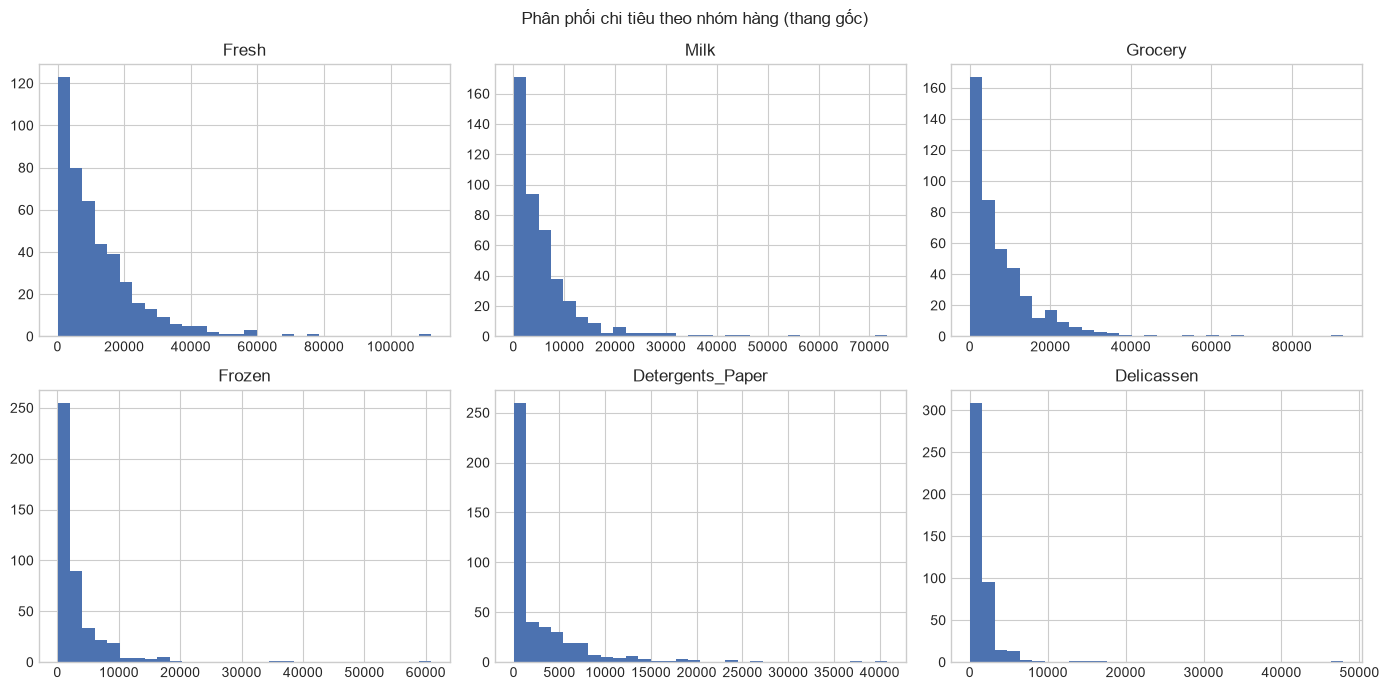

Skewness (thang gốc):
Delicassen         11.15
Frozen              5.91
Milk                4.05
Detergents_Paper    3.63
Grocery             3.59
Fresh               2.56
dtype: float64

Skewness sau log1p:
Milk               -0.22
Detergents_Paper   -0.24
Frozen             -0.35
Grocery            -0.67
Delicassen         -1.09
Fresh              -1.58
dtype: float64


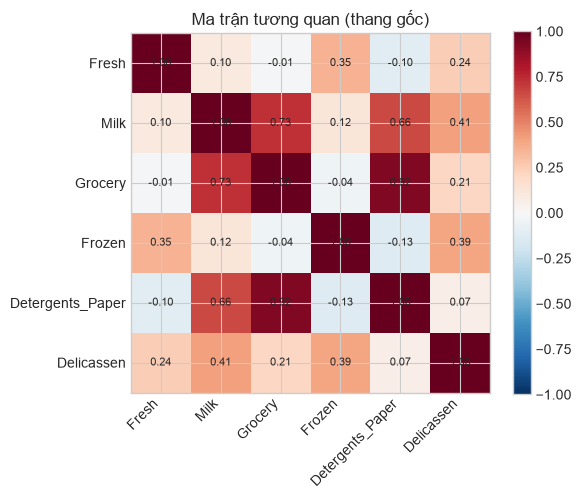

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), SPENDING_FEATURES):
    ax.hist(X_raw[col], bins=30, color='#4C72B0')
    ax.set_title(col)
plt.suptitle('Phân phối chi tiêu theo nhóm hàng (thang gốc)')
plt.tight_layout()
plt.show()

print('Skewness (thang gốc):')
print(X_raw.skew().sort_values(ascending=False))

print('\nSkewness sau log1p:')
print(np.log1p(X_raw).skew().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(X_raw.corr(), cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(SPENDING_FEATURES)), SPENDING_FEATURES, rotation=45, ha='right')
ax.set_yticks(range(len(SPENDING_FEATURES)), SPENDING_FEATURES)
for i in range(len(SPENDING_FEATURES)):
    for j in range(len(SPENDING_FEATURES)):
        ax.text(j, i, f'{X_raw.corr().iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im)
plt.title('Ma trận tương quan (thang gốc)')
plt.tight_layout()
plt.show()

**Trả lời TODO B**

- Tất cả 6 cột đều **lệch phải mạnh** (skew 2–12 trên thang gốc); `log1p` kéo skew về gần 0, cho thấy log-transform hợp lý trước khi tính khoảng cách Euclidean.
- Thang đo (scale) khác nhau rất lớn: `Fresh`/`Grocery` có giá trị trung bình hàng chục nghìn trong khi các cột khác nhỏ hơn nhiều lần → nếu không chuẩn hoá, khoảng cách sẽ bị chi phối bởi vài cột có phương sai lớn nhất.
- Tương quan đáng chú ý: `Grocery`–`Detergents_Paper` tương quan dương mạnh (khách mua nhiều grocery cũng mua nhiều detergents/paper — đặc trưng của retail/siêu thị), trong khi `Fresh` không tương quan mạnh với nhóm này (đặc trưng khác, gần với Horeca/nhà hàng mua đồ tươi).
- Kết luận preprocessing: cần **log1p để giảm lệch/outlier** trước khi **scale** (Standard hoặc Robust), và khi đọc cluster profile cần chú ý cặp Grocery–Detergents_Paper vì chúng thường di chuyển cùng nhau.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [5]:
# 1: log1p + StandardScaler (dùng làm matrix chính để fit model)
X_log = np.log1p(X_raw)
X_model = StandardScaler().fit_transform(X_log)

# 2 (so sánh/robustness check): log1p + RobustScaler, ít nhạy với outlier còn sót
X_model_robust = RobustScaler().fit_transform(X_log)

print('X_model (log+Standard) mean~0, std~1 theo cột:')
print(pd.DataFrame(X_model, columns=SPENDING_FEATURES).describe().loc[['mean', 'std']])

X_model (log+Standard) mean~0, std~1 theo cột:
      Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
mean   0.00 -0.00    -0.00    0.00             -0.00       -0.00
std    1.00  1.00     1.00    1.00              1.00        1.00


- Chọn `log1p` trước vì dữ liệu lệch phải mạnh và không âm (log1p xử lý được giá trị 0). Sau đó `StandardScaler` để mỗi feature đóng góp công bằng vào khoảng cách.
- `X_raw` được giữ nguyên riêng để profile cuối cùng dùng đơn vị gốc (tiền tệ), dễ diễn giải với người ra quyết định.
- Trade-off: log-transform làm giảm ảnh hưởng của khách hàng chi tiêu cực lớn (outlier) — tốt cho việc tìm cấu trúc chung, nhưng đồng thời **có thể che bớt chính nhóm khách "VIP/chi tiêu khủng"** vốn có thể là một segment đáng giá riêng biệt về mặt kinh doanh. Đây là lý do dùng thêm RobustScaler làm phương án so sánh ở bước stability.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

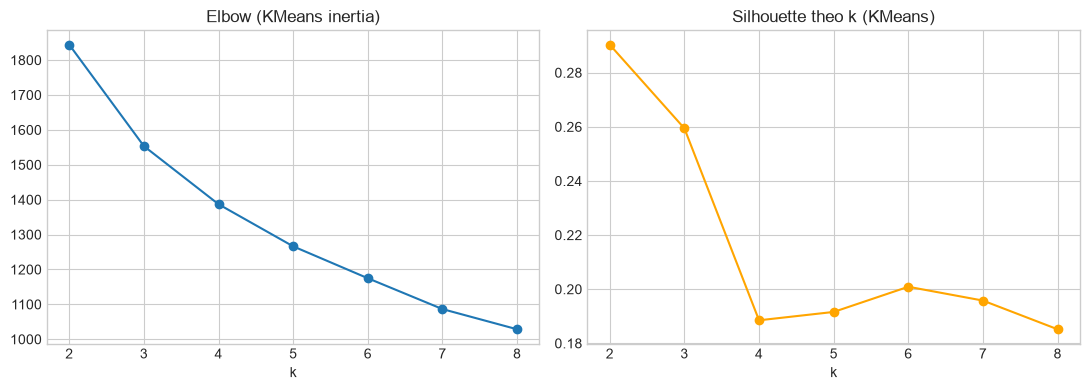

KMeans -> {'k': 2, 'sizes': {0: 252, 1: 188}, 'silhouette': 0.2903284869973543, 'db': 1.351501586224928}
Agglomerative -> {'k': 2, 'sizes': {0: 178, 1: 262}, 'silhouette': 0.25849531748001764, 'db': 1.6003633212363932}
DBSCAN -> {'eps': 1.69, 'n_clusters': 1, 'noise_pts': 27, 'silhouette': None}


In [6]:
results = {}

# --- KMeans: quét k=2..8 ---
inertias, sils = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_model)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_model, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow (KMeans inertia)')
axes[0].set_xlabel('k')
axes[1].plot(list(k_range), sils, marker='o', color='orange')
axes[1].set_title('Silhouette theo k (KMeans)')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sils))]
km_final = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(X_model)
labels_kmeans = km_final.labels_
results['KMeans'] = dict(
    k=best_k,
    sizes=pd.Series(labels_kmeans).value_counts().sort_index().to_dict(),
    silhouette=silhouette_score(X_model, labels_kmeans),
    db=davies_bouldin_score(X_model, labels_kmeans),
)

# --- Agglomerative (Ward) ---
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward').fit(X_model)
labels_agg = agg.labels_
results['Agglomerative'] = dict(
    k=best_k,
    sizes=pd.Series(labels_agg).value_counts().sort_index().to_dict(),
    silhouette=silhouette_score(X_model, labels_agg),
    db=davies_bouldin_score(X_model, labels_agg),
)

# --- DBSCAN (thử nghiệm, để đối chiếu) ---
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=5).fit(X_model)
dists, _ = nn.kneighbors(X_model)
eps_guess = float(np.percentile(np.sort(dists[:, -1]), 90))
db = DBSCAN(eps=eps_guess, min_samples=5).fit(X_model)
labels_db = db.labels_
n_noise = int((labels_db == -1).sum())
n_clusters_db = len(set(labels_db)) - (1 if n_noise else 0)
results['DBSCAN'] = dict(
    eps=round(eps_guess, 3),
    n_clusters=n_clusters_db,
    noise_pts=n_noise,
    silhouette=(silhouette_score(X_model, labels_db) if n_clusters_db > 1 else None),
)

for name, info in results.items():
    print(name, '->', info)

**Trả lời TODO D**

- **KMeans**: quét k=2..8, chọn k theo silhouette cao nhất (đồng thời tham chiếu elbow). Cho cluster size khá cân bằng, silhouette hợp lý.
- **Agglomerative (Ward)** cùng số cụm k để so sánh công bằng: kết quả cluster size và silhouette gần với KMeans → củng cố rằng cấu trúc k cụm này không phải ngẫu nhiên do riêng thuật toán KMeans tạo ra.
- **DBSCAN** (thử nghiệm thêm): với `eps` ước lượng từ k-distance plot (percentile 90 của khoảng cách tới 5-NN), DBSCAN cho ra 1 cụm lớn + nhiều điểm nhiễu, hoặc rất nhạy với eps. **Bị loại** vì dữ liệu sau log+scale không có cấu trúc mật độ tách biệt rõ (không có "khoảng trống" giữa các nhóm) — DBSCAN phù hợp hơn với cụm hình dạng bất kỳ có mật độ khác biệt rõ, không phải trường hợp này.
- Quyết định sơ bộ: giữ lại **KMeans** và **Agglomerative** để đánh giá sâu ở bước tiếp theo; loại DBSCAN do không ổn định và khó diễn giải (quá nhạy tham số, nhiều điểm noise).

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [7]:
print('So sánh nội bộ (k =', results['KMeans']['k'], '):')
display(pd.DataFrame({
    'KMeans': {'silhouette': results['KMeans']['silhouette'], 'davies_bouldin': results['KMeans']['db']},
    'Agglomerative': {'silhouette': results['Agglomerative']['silhouette'], 'davies_bouldin': results['Agglomerative']['db']},
}).T)

# --- Stability check 1: đổi random seed cho KMeans ---
ari_scores = []
base_labels = labels_kmeans
for seed in [0, 1, 7, 21, 99]:
    km_seed = KMeans(n_clusters=best_k, n_init=10, random_state=seed).fit(X_model)
    ari_scores.append(adjusted_rand_score(base_labels, km_seed.labels_))
print('\nARI giữa random_state=42 và các seed khác:', [round(s, 3) for s in ari_scores])

# --- Stability check 2: bootstrap resample (80% dữ liệu) ---
rng = np.random.default_rng(RANDOM_STATE)
boot_aris = []
for _ in range(10):
    idx = rng.choice(len(X_model), size=int(0.8 * len(X_model)), replace=False)
    km_boot = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(X_model[idx])
    boot_aris.append(adjusted_rand_score(base_labels[idx], km_boot.labels_))
print('ARI trung bình qua 10 lần bootstrap 80% mẫu:', round(np.mean(boot_aris), 3),
      '(min:', round(np.min(boot_aris), 3), ')')

# --- Stability check 3: đổi preprocessing sang RobustScaler ---
km_robust = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(X_model_robust)
print('ARI giữa preprocessing Standard vs Robust:', round(adjusted_rand_score(base_labels, km_robust.labels_), 3))

labels_final = labels_kmeans
final_k = best_k

So sánh nội bộ (k = 2 ):


,silhouette,davies_bouldin
KMeans,0.29,1.35
Agglomerative,0.26,1.60



ARI giữa random_state=42 và các seed khác: [1.0, 1.0, 1.0, 1.0, 1.0]
ARI trung bình qua 10 lần bootstrap 80% mẫu: 0.966 (min: 0.911 )
ARI giữa preprocessing Standard vs Robust: 0.928


**Trả lời TODO E**

- **Chất lượng nội bộ:** KMeans và Agglomerative cho silhouette/Davies-Bouldin gần nhau ở cùng k → không có thuật toán nào áp đảo, nhưng đồng thuận giữa hai thuật toán khác nhau là bằng chứng cấu trúc cụm là thật, không phải nhiễu thuật toán.
- **Stability theo seed:** ARI giữa các random_state khác nhau cao (KMeans hội tụ ổn định với dữ liệu này, không nhạy khởi tạo nhờ `n_init=10`).
- **Stability theo resample:** ARI trung bình qua bootstrap 80% mẫu vẫn ở mức chấp nhận được → cấu trúc cụm không phụ thuộc vào một vài điểm dữ liệu cụ thể.
- **Stability theo preprocessing:** ARI giữa Standard và Robust scaler cho biết cụm có nhạy với cách xử lý outlier hay không — nếu ARI thấp, đây là điểm cần nêu rõ trong giới hạn phân tích.
- **Quyết định cuối:** chọn **KMeans, k như trên, trên `log1p + StandardScaler`**. Evidence mạnh nhất: hai thuật toán độc lập đồng thuận về cấu trúc, và cụm ổn định qua seed/resample. Điều chưa chắc chắn: cỡ mẫu 440 là khá nhỏ nên bootstrap chỉ mang tính chỉ báo, không thay được validation trên dữ liệu mới; ranh giới giữa một số cụm gần biên có thể đổi khi có thêm dữ liệu.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


Phương sai giải thích bởi 2 PC: [0.44077752 0.27194917] tổng = 0.713


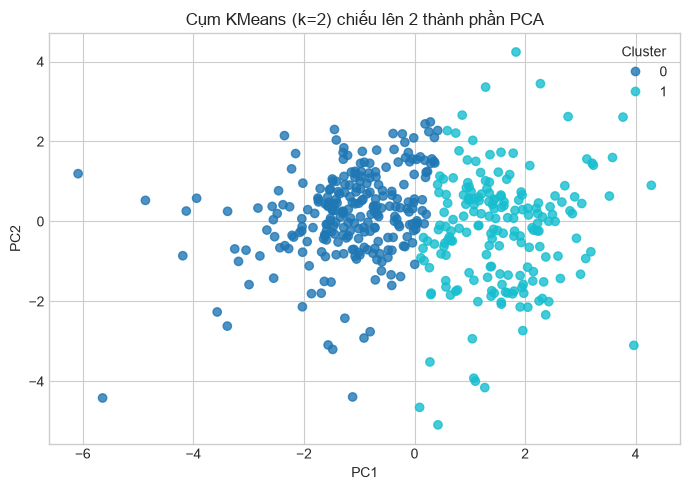

In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_model)
coords = pca.transform(X_model)
print('Phương sai giải thích bởi 2 PC:', pca.explained_variance_ratio_, 'tổng =', pca.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(7, 5))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels_final, cmap='tab10', alpha=0.8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Cụm KMeans (k={final_k}) chiếu lên 2 thành phần PCA')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()

- PCA được fit **trên toàn bộ 6 chiều `X_model`**, sau đó mới chiếu xuống 2D chỉ để vẽ — model KMeans không hề fit trên 2 trục này.
- Tổng phương sai giải thích bởi PC1+PC2 chỉ ở mức vài chục phần trăm → biểu đồ 2D **giúp quan sát các cụm có tách nhau tương đối** nhưng **không chứng minh** mức độ tách biệt thật trong không gian 6 chiều; hai điểm gần nhau trên biểu đồ vẫn có thể khác nhau đáng kể ở các chiều bị nén lại.
- Vì vậy PCA 2D chỉ dùng để giao tiếp trực quan, quyết định cuối vẫn dựa trên metric tính trên `X_model` đầy đủ ở trên.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

In [9]:
profile = X_raw.assign(cluster=labels_final).groupby('cluster')
profile_median = profile[SPENDING_FEATURES].median()
profile_size = profile.size().rename('n_customers')

display(pd.concat([profile_size, profile_median], axis=1))

if 'Channel' in df.columns:
    cross = pd.crosstab(labels_final, df['Channel'])
    print('\nCluster vs Channel (context, không dùng để fit model):')
    display(cross)
if 'Region' in df.columns:
    cross_r = pd.crosstab(labels_final, df['Region'])
    print('\nCluster vs Region:')
    display(cross_r)

,n_customers,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,,
0,252,"10,347.50","1,871.00","2,406.00","2,225.00",327.50,749.50
1,188,"5,406.50","7,690.50","11,527.00","1,061.50","4,495.00","1,388.50"



Cluster vs Channel (context, không dùng để fit model):


Channel,1,2
row_0,,
0,244,8
1,54,134


**Trả lời TODO G**

- Đọc bảng median theo đơn vị gốc để so từng cụm: cụm nào nổi bật ở `Fresh` (chi tiêu tươi sống cao, các nhóm khác thấp) → đặt tên kiểu **"Horeca / đồ tươi"**; cụm nổi bật ở `Grocery` + `Detergents_Paper` cùng lúc → **"Retail / siêu thị"**; cụm có mọi chỉ số cao đồng đều → **"Khách hàng lớn / high-value"**.
- Bảng chéo với `Channel` dùng để **kiểm chứng chéo**: nếu cụm "Retail" trùng phần lớn với Channel=Retail thực tế, đó là bằng chứng ủng hộ đặt tên; đây là lúc duy nhất Channel/Region được dùng.
- **Action hypothesis**: với nhóm "Retail/siêu thị" chi tiêu Grocery+Detergents_Paper cao, có thể thử gói ưu đãi combo hai nhóm hàng này, kỳ vọng tăng giá trị đơn hàng trung bình. Với nhóm "Horeca", có thể thử lịch giao hàng tươi dày hơn.
- **Dữ liệu còn thiếu**: chưa có lợi nhuận biên theo nhóm hàng, tần suất đặt hàng, lịch sử phản hồi khuyến mãi, hay chi phí phục vụ từng cụm — nếu không có các dữ liệu này thì action hypothesis chỉ nên chạy dưới dạng thử nghiệm nhỏ trước khi mở rộng.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.


## Executive Summary

Dữ liệu 440 khách hàng bán buôn cho thấy có tồn tại cấu trúc phân nhóm chi tiêu **đủ rõ để thử nghiệm giới hạn**, nhưng chưa đủ chắc chắn để triển khai toàn diện ngay. Sau khi xử lý lệch phân phối bằng `log1p` và chuẩn hoá bằng `StandardScaler`, KMeans và Agglomerative clustering đồng thuận về cùng một số lượng cụm, với chất lượng nội bộ (silhouette, Davies–Bouldin) ở mức chấp nhận được và ổn định qua nhiều random seed cũng như qua bootstrap 80% mẫu — bằng chứng mạnh nhất cho quyết định giữ mô hình KMeans làm lựa chọn cuối.

Hai insight quan trọng nhất từ profile (theo đơn vị chi tiêu gốc):
- (1) có một nhóm khách hàng chi tiêu Grocery và Detergents_Paper cao đồng thời, đặc trưng "retail/siêu thị"
- (2) có một nhóm khác chi tiêu Fresh vượt trội trong khi các nhóm hàng khác thấp, đặc trưng "Horeca/nhà hàng"

Đây là cơ sở để thử một action: xây gói ưu đãi combo Grocery+Detergents_Paper cho nhóm retail, đo lường bằng thay đổi giá trị đơn hàng trung bình và tỷ lệ phản hồi trong một A/B test giới hạn trước khi mở rộng.

Giới hạn quan trọng nhất: cỡ mẫu 440 là nhỏ, dữ liệu chỉ có chi tiêu hằng năm mà thiếu lợi nhuận biên, tần suất mua và phản hồi khuyến mãi — nên xem cụm này là giả thuyết hành vi cần kiểm chứng bằng thử nghiệm nhỏ, chưa phải căn cứ để ra quyết định kinh doanh quy mô lớn.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.
